# Human Supplement: People vs. LLMs on LifeEval

A preregistered human study (AsPredicted #267677; see [`../human-data/`](../human-data/README.md))
asked MTurk participants the same LifeEval questions the LLMs answer in this study:
point-estimate an American {male|female}'s age at death given survival to a minimum age,
then state confidence that the estimate is within a radius of the truth.

- **Humans:** 98 participants x 10 items = 980 observations over 88 conditions
  (ages {1,10,...,100} x 2 sexes x radii {1,5,10,20}).
- **LLMs:** the 4 DCE models from `../results/LifeEval/`, filtered to the same 88 cells.
- **Common ground truth:** both are scored with this study's Gompertz rule
  (`scoring.lifeeval_true_probability`), so calibration is directly comparable.

In [1]:
import re
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

from scoring import lifeeval_true_probability, murphy_decomposition
from evaluate_diff import add_difficulty

sns.set_theme(style="whitegrid")
FIGS = Path("figs/human_supplement")
FIGS.mkdir(parents=True, exist_ok=True)

HUMAN_LABEL = "Humans"
MODEL_FILES = {
    "Claude Haiku 4.5": "anthropic_claude-haiku-4.5.csv",
    "Gemini 2.5 Flash": "google_gemini-2.5-flash.csv",
    "Llama 4 Maverick": "meta-llama_llama-4-maverick.csv",
    "GPT-5.4 Mini": "openai_gpt-5.4-mini.csv",
}
HUMAN_AGES = [1, 10, 20, 30, 40, 50, 60, 70, 80, 90, 100]
HUMAN_RADII = [1, 5, 10, 20]

## Load and score the human data

`PConf` is 0-100 -> rescale to 0-1. Each observation is scored with the Gompertz
window probability `P(death in [guess-r, guess+r) | survived to min_age)`.

In [2]:
human = pd.read_csv("../human-data/cleaned/260113LEHcleaned.csv")

human = human.rename(columns={"PGuess": "Answer", "MinAge": "min_age", "Radius": "radius"})
human["Confidence"] = human["PConf"] / 100
human["sex"] = np.where(human["SexMale"] == 1, "male", "female")
human["true_probability"] = [
    lifeeval_true_probability(a, age, sex, r)
    for a, age, sex, r in zip(human["Answer"], human["min_age"], human["sex"], human["radius"])
]
human["brier"] = (human["Confidence"] - human["true_probability"]) ** 2

assert len(human) == 980 and human["ResponseId"].nunique() == 98
assert human["true_probability"].between(0, 1).all()
assert human.groupby(["min_age", "sex", "radius"]).ngroups == 88
human[["Answer", "Confidence", "min_age", "sex", "radius", "true_probability"]].head()

,Answer,Confidence,min_age,sex,radius,true_probability
0,80,0.89,1,female,5,0.296088
1,80,0.72,60,female,5,0.317457
2,85,0.73,10,female,10,0.625464
3,75,0.50,70,female,10,0.469363
4,90,1.00,1,male,1,0.049838


### Sensitivity: Gompertz vs. the empirical life-table rule

`../human-data/cleaned/fin_le_data.csv` carries the same observations scored under
study 1's empirical SSA life-table rule. If the two ground-truth rules agree, the
choice of rule cannot drive any conclusion below.

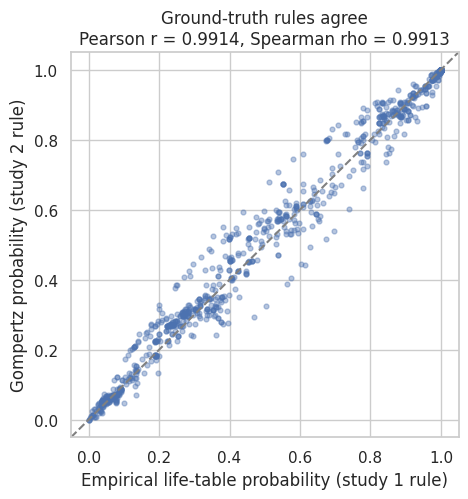

Pearson r = 0.9914, Spearman rho = 0.9913, n = 980


In [3]:
fin = pd.read_csv("../human-data/cleaned/fin_le_data.csv")
merged = human.merge(
    fin[["ResponseId", "LifeEvalQ", "Score"]],
    on=["ResponseId", "LifeEvalQ"],
    how="inner",
    validate="one_to_one",
)
r_pearson = merged["true_probability"].corr(merged["Score"])
r_spearman = merged["true_probability"].corr(merged["Score"], method="spearman")

fig, ax = plt.subplots(figsize=(5, 5))
ax.scatter(merged["Score"], merged["true_probability"], s=12, alpha=0.4)
ax.axline([0, 0], [1, 1], color="grey", linestyle="--")
ax.set_xlabel("Empirical life-table probability (study 1 rule)")
ax.set_ylabel("Gompertz probability (study 2 rule)")
ax.set_title(f"Ground-truth rules agree\nPearson r = {r_pearson:.4f}, Spearman rho = {r_spearman:.4f}")
fig.savefig(FIGS / "scoring_rule_sensitivity.png", dpi=300, bbox_inches="tight")
plt.show()
print(f"Pearson r = {r_pearson:.4f}, Spearman rho = {r_spearman:.4f}, n = {len(merged)}")

## Load the LLM results on the matched 88 cells

In [4]:
# Question attributes come from the canonical benchmark (one result file
# carries stale _x/_y merge suffixes), joined on question_id.
bench_attrs = pd.read_csv("../domains/LifeEval/Data/benchmark.csv")[
    ["question_id", "min_age", "sex", "radius"]
]

frames = []
for label, filename in MODEL_FILES.items():
    df = pd.read_csv(Path("../results/LifeEval") / filename)
    df = df.drop(columns=[c for c in df.columns if re.match(r"(min_age|sex|radius|true_lifespan|best_answer|MAS)", c)])
    df = df.merge(bench_attrs, on="question_id", how="inner", validate="one_to_one")
    df = df[df["min_age"].isin(HUMAN_AGES) & df["radius"].isin(HUMAN_RADII)].copy()
    df["Answer"] = pd.to_numeric(
        df["Answer"].astype(str).str.extract(r"([\d.]+)")[0], errors="coerce"
    )
    df["Confidence"] = pd.to_numeric(df["Confidence"], errors="coerce")
    df = df.dropna(subset=["Answer", "Confidence"])
    df["true_probability"] = [
        lifeeval_true_probability(a, age, sex, r)
        for a, age, sex, r in zip(df["Answer"], df["min_age"], df["sex"], df["radius"])
    ]
    df["brier"] = (df["Confidence"] - df["true_probability"]) ** 2
    df["agent"] = label
    frames.append(df)
    assert df.groupby(["min_age", "sex", "radius"]).ngroups == 88, label

llms = pd.concat(frames, ignore_index=True)
human["agent"] = HUMAN_LABEL
COMMON = ["agent", "Answer", "Confidence", "min_age", "sex", "radius", "true_probability", "brier"]
everyone = pd.concat([llms[COMMON], human[COMMON]], ignore_index=True)
AGENTS = [HUMAN_LABEL] + list(MODEL_FILES)
everyone.groupby("agent").size()

agent
Claude Haiku 4.5     88
GPT-5.4 Mini         88
Gemini 2.5 Flash     88
Humans              980
Llama 4 Maverick     88
dtype: int64

## Calibration curves

Binned stated confidence vs. mean realized (Gompertz) probability, with 95% CIs.

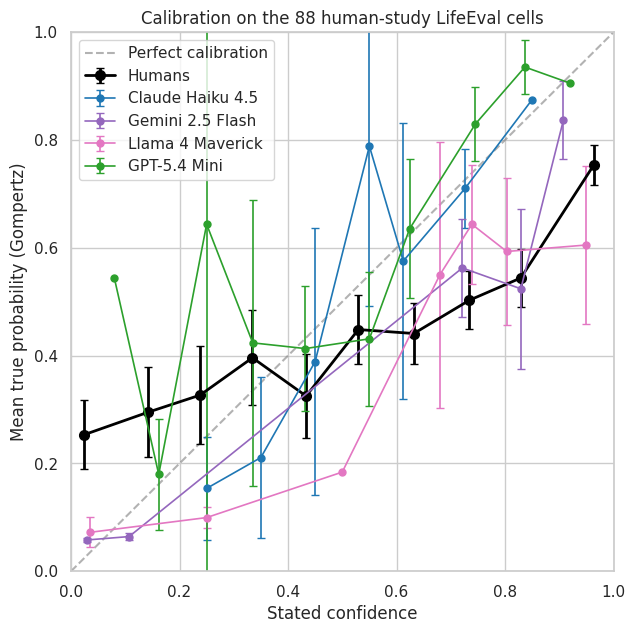

In [5]:
def reliability(df, n_bins=10):
    out = df.copy()
    out["bin"] = np.clip((out["Confidence"] * n_bins).astype(int), 0, n_bins - 1)
    g = out.groupby("bin").agg(
        mean_conf=("Confidence", "mean"),
        mean_prob=("true_probability", "mean"),
        std_prob=("true_probability", "std"),
        n=("true_probability", "size"),
    ).reset_index()
    g["ci"] = 1.96 * g["std_prob"] / np.sqrt(g["n"])
    return g


palette = dict(zip(AGENTS, ["black", "#1f77b4", "#9467bd", "#e377c2", "#2ca02c"]))
fig, ax = plt.subplots(figsize=(7, 7))
ax.axline([0, 0], [1, 1], color="grey", linestyle="--", alpha=0.6, label="Perfect calibration")
for agent in AGENTS:
    g = reliability(everyone[everyone["agent"] == agent])
    ax.errorbar(g["mean_conf"], g["mean_prob"], yerr=g["ci"], fmt="o-",
                capsize=3, label=agent, color=palette[agent],
                linewidth=2 if agent == HUMAN_LABEL else 1.2,
                markersize=7 if agent == HUMAN_LABEL else 5)
ax.set_xlim(0, 1)
ax.set_ylim(0, 1)
ax.set_xlabel("Stated confidence")
ax.set_ylabel("Mean true probability (Gompertz)")
ax.set_title("Calibration on the 88 human-study LifeEval cells")
ax.legend(loc="upper left")
fig.savefig(FIGS / "calibration_human_vs_llm.png", dpi=300, bbox_inches="tight")
plt.show()

## Overconfidence and proper-score summary

Overconfidence = mean(confidence) - mean(true probability). Murphy decomposition:
`BS = Reliability - Resolution + Uncertainty` (lower Brier / reliability is better,
higher resolution is better).

In [6]:
rows = []
for agent in AGENTS:
    sub = everyone[everyone["agent"] == agent]
    m = murphy_decomposition(sub)
    rows.append({
        "agent": agent,
        "n": len(sub),
        "mean_confidence": sub["Confidence"].mean(),
        "mean_true_prob": sub["true_probability"].mean(),
        "overconfidence": sub["Confidence"].mean() - sub["true_probability"].mean(),
        **m,
    })
summary = pd.DataFrame(rows).set_index("agent")
summary.round(4)

,n,mean_confidence,mean_true_prob,overconfidence,reliability,resolution,uncertainty,brier
agent,,,,,,,,
Humans,980,0.6350,0.5079,0.1271,0.0402,0.0262,0.1321,0.1318
Claude Haiku 4.5,88,0.5905,0.5565,0.0340,0.0067,0.0513,0.1304,0.0704
Gemini 2.5 Flash,88,0.6990,0.5468,0.1521,0.0290,0.0366,0.1298,0.1093
Llama 4 Maverick,88,0.6857,0.5063,0.1793,0.0496,0.0438,0.1258,0.1295
GPT-5.4 Mini,88,0.5181,0.5604,-0.0423,0.0103,0.0745,0.1313,0.0518


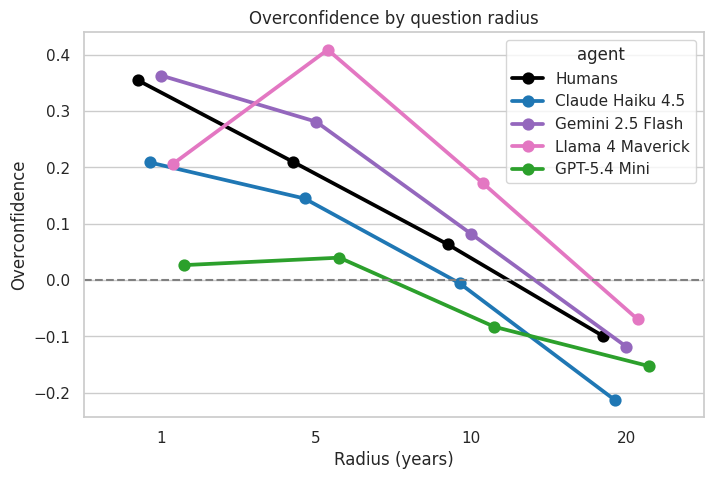

agent,Claude Haiku 4.5,GPT-5.4 Mini,Gemini 2.5 Flash,Humans,Llama 4 Maverick
radius,,,,,
1,0.209,0.027,0.363,0.355,0.206
5,0.145,0.040,0.281,0.210,0.409
10,-0.005,-0.083,0.082,0.063,0.172
20,-0.212,-0.153,-0.118,-0.099,-0.070


In [7]:
oc_rad = (
    everyone.groupby(["agent", "radius"])
    .apply(lambda d: d["Confidence"].mean() - d["true_probability"].mean(), include_groups=False)
    .rename("overconfidence")
    .reset_index()
)
fig, ax = plt.subplots(figsize=(8, 5))
sns.pointplot(data=oc_rad, x="radius", y="overconfidence", hue="agent",
              hue_order=AGENTS, palette=palette, dodge=0.3, ax=ax)
ax.axhline(0, color="grey", linestyle="--")
ax.set_xlabel("Radius (years)")
ax.set_ylabel("Overconfidence")
ax.set_title("Overconfidence by question radius")
fig.savefig(FIGS / "overconfidence_by_radius.png", dpi=300, bbox_inches="tight")
plt.show()
oc_rad.pivot(index="radius", columns="agent", values="overconfidence").round(3)

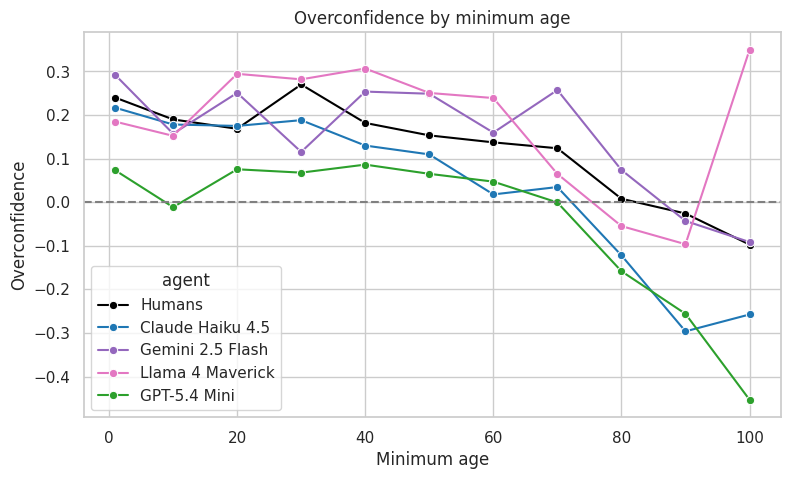

In [8]:
oc_age = (
    everyone.groupby(["agent", "min_age"])
    .apply(lambda d: d["Confidence"].mean() - d["true_probability"].mean(), include_groups=False)
    .rename("overconfidence")
    .reset_index()
)
fig, ax = plt.subplots(figsize=(9, 5))
sns.lineplot(data=oc_age, x="min_age", y="overconfidence", hue="agent",
             hue_order=AGENTS, palette=palette, marker="o", ax=ax)
ax.axhline(0, color="grey", linestyle="--")
ax.set_xlabel("Minimum age")
ax.set_ylabel("Overconfidence")
ax.set_title("Overconfidence by minimum age")
fig.savefig(FIGS / "overconfidence_by_age.png", dpi=300, bbox_inches="tight")
plt.show()

## Per-cell comparison

Collapse to the 88 (age, sex, radius) cells and compare each LLM's confidence and
realized probability against the human cell means.

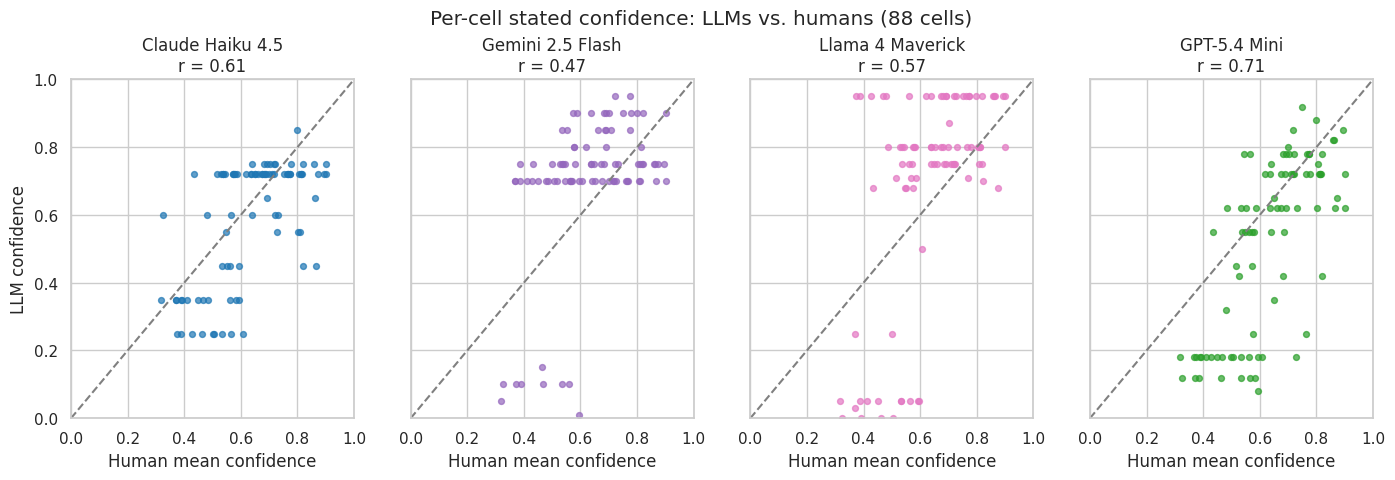

In [9]:
cells_df = (
    everyone.groupby(["agent", "min_age", "sex", "radius"])[["Confidence", "true_probability"]]
    .mean()
    .reset_index()
)
hcells = cells_df[cells_df["agent"] == HUMAN_LABEL].drop(columns="agent")
fig, axes = plt.subplots(1, len(MODEL_FILES), figsize=(4.2 * len(MODEL_FILES), 4.4), sharey=True)
for ax, agent in zip(axes, MODEL_FILES):
    mc = cells_df[cells_df["agent"] == agent].merge(
        hcells, on=["min_age", "sex", "radius"], suffixes=("_llm", "_human")
    )
    r = mc["Confidence_llm"].corr(mc["Confidence_human"])
    ax.scatter(mc["Confidence_human"], mc["Confidence_llm"], s=18, alpha=0.7, color=palette[agent])
    ax.axline([0, 0], [1, 1], color="grey", linestyle="--")
    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1)
    ax.set_title(f"{agent}\nr = {r:.2f}")
    ax.set_xlabel("Human mean confidence")
axes[0].set_ylabel("LLM confidence")
fig.suptitle("Per-cell stated confidence: LLMs vs. humans (88 cells)", y=1.04)
fig.savefig(FIGS / "per_cell_confidence.png", dpi=300, bbox_inches="tight")
plt.show()

## Hard-easy effect

Difficulty is the Eckhardt-Lee rank percentile from `evaluate_diff.py`, computed on the
**full 4,040-question DCE grid** so the human items sit on the same percentile scale used
in the main analysis (higher percentile = harder for a uniform guesser).

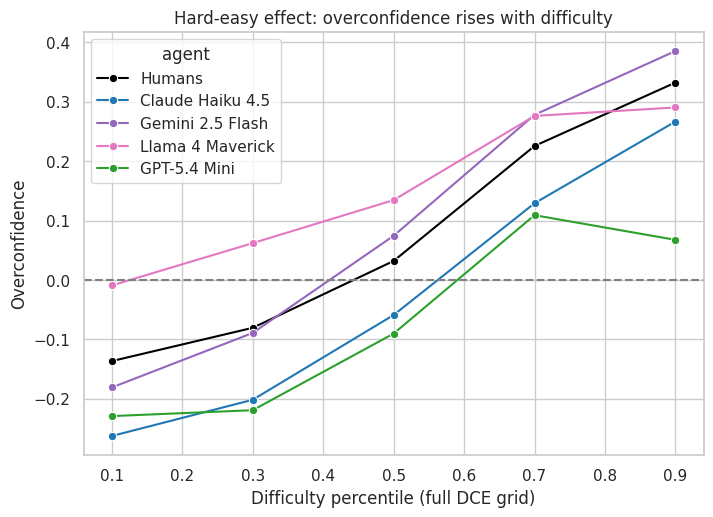

Humans              0.600
Claude Haiku 4.5    0.660
Gemini 2.5 Flash    0.696
Llama 4 Maverick    0.384
GPT-5.4 Mini        0.405
Name: OC-vs-difficulty slope, dtype: float64

In [10]:
bench = pd.read_csv("../domains/LifeEval/Data/benchmark.csv")
bench = add_difficulty(bench, "LifeEval")
diff_map = bench.set_index(["min_age", "sex", "radius"])["diff"]

everyone["diff"] = everyone.set_index(["min_age", "sex", "radius"]).index.map(diff_map)
assert everyone["diff"].notna().all()

everyone["diff_bin"] = pd.cut(everyone["diff"], bins=np.linspace(0, 1, 6))
he = (
    everyone.groupby(["agent", "diff_bin"], observed=True)
    .apply(lambda d: d["Confidence"].mean() - d["true_probability"].mean(), include_groups=False)
    .rename("overconfidence")
    .reset_index()
)
he["diff_mid"] = he["diff_bin"].apply(lambda iv: iv.mid).astype(float)

fig, ax = plt.subplots(figsize=(8, 5.5))
sns.lineplot(data=he, x="diff_mid", y="overconfidence", hue="agent",
             hue_order=AGENTS, palette=palette, marker="o", ax=ax)
ax.axhline(0, color="grey", linestyle="--")
ax.set_xlabel("Difficulty percentile (full DCE grid)")
ax.set_ylabel("Overconfidence")
ax.set_title("Hard-easy effect: overconfidence rises with difficulty")
fig.savefig(FIGS / "hard_easy_effect.png", dpi=300, bbox_inches="tight")
plt.show()

slopes = {}
for agent in AGENTS:
    sub = everyone[everyone["agent"] == agent]
    oc = sub["Confidence"] - sub["true_probability"]
    slopes[agent] = np.polyfit(sub["diff"], oc, 1)[0]
pd.Series(slopes, name="OC-vs-difficulty slope").round(3)

## Takeaways

- **The two ground-truth rules are interchangeable** (Pearson r = 0.991 between the
  Gompertz and empirical life-table probabilities on the human responses), so nothing
  below hinges on the scoring-rule choice.
- **Humans are overconfident on LifeEval** (+0.127 overall: mean confidence 0.64 vs.
  mean realized probability 0.51), consistent with the preregistered hypothesis.
- **Humans sit inside the LLM range.** Gemini 2.5 Flash (+0.152) and Llama 4 Maverick
  (+0.179) are *more* overconfident than people; Claude Haiku 4.5 (+0.034) and
  GPT-5.4 Mini (-0.042) are close to calibrated on these cells.
- **Everyone shows the same radius pattern:** overconfident on the hardest, narrowest
  windows (r = 1) and underconfident on the widest (r = 20) — humans go from +0.36 at
  r = 1 to -0.10 at r = 20.
- **The hard-easy effect is not machine-specific.** Regressing item-level
  overconfidence on the Eckhardt-Lee difficulty percentile gives positive slopes for
  every agent (0.38-0.70); the human slope (0.60) is squarely within the LLM range.
- **By Brier score humans do worst** (0.132 vs. 0.070-0.126 for the LLMs), driven by
  both a larger reliability penalty and lower resolution.

Caveats: LLM cells carry one response each vs. ~11 human responses per cell; human
confidence came from a 0-100 slider (granularity differs from the LLMs' JSON decimals);
and participants are MTurk workers, not a representative sample.
